# 太阳能电池实验

## 五、实验数据

In [55]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

### 1. 在无光源条件下，测量硅光电池正向偏压时的伏安特性。

In [56]:
with open("data1.csv", "r") as f:
    df: pd.DataFrame = pd.read_csv(f)
    df = df[df["I/mA"] != 0]
    vol, cur = [df[col].to_numpy() for col in df.columns]
    del df

ln_cur = np.log(cur)

ft = sk.linear_model.LinearRegression().fit(vol.reshape(-1, 1), ln_cur.reshape(-1, 1))

print("ln(i) = {:f} * u + {:f}".format(ft.coef_[0][0], ft.intercept_[0]))
print("R^2 = {:f}".format(ft.score(vol.reshape(-1, 1), ln_cur.reshape(-1, 1))))

ln(i) = 1.284436 * u + -4.895502
R^2 = 0.991030


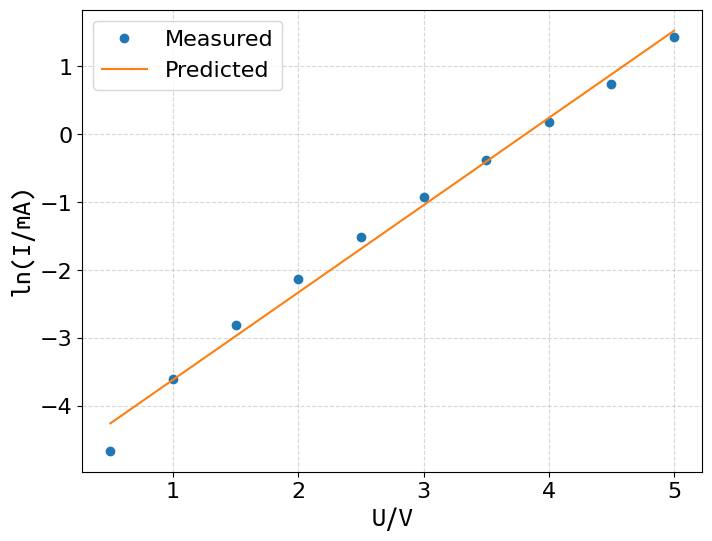

In [57]:
# Plot the data points and the regressed line
plt.figure(figsize=(8, 6))
plt.plot(vol, ln_cur, "o", label="Measured")
plt.plot(vol, ft.predict(vol.reshape(-1, 1)), label="Predicted")
plt.legend(fontsize=16)
plt.xlabel("U/V", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.xticks(fontsize=16)
plt.ylabel("ln(I/mA)", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

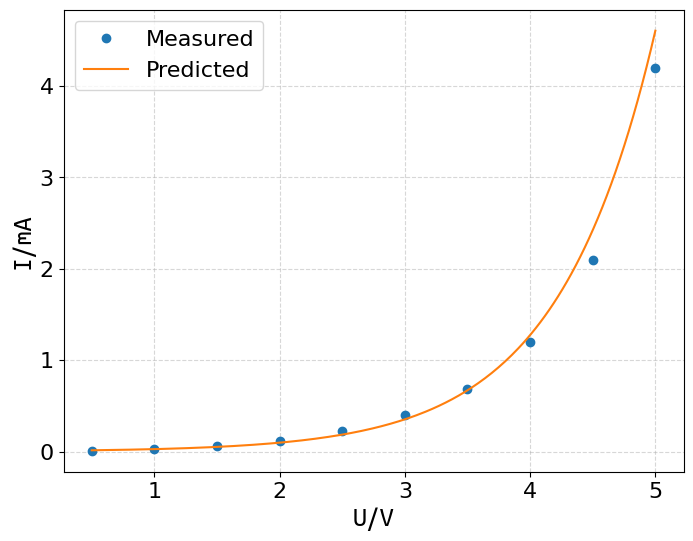

In [58]:
plt.figure(figsize=(8, 6))
plt.plot(vol, cur, "o", label="Measured")
N = 256
x = np.linspace(np.min(vol), np.max(vol), N)
plt.plot(x, np.exp(ft.predict(x.reshape(-1, 1))), label="Predicted")
del N, x
plt.legend(fontsize=16)
plt.xlabel("U/V", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.xticks(fontsize=16)
plt.ylabel("I/mA", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 3. 测量太阳能电池板的负载特性

In [59]:
with open("data2.csv", "r+") as f:
    df: pd.DataFrame = pd.read_csv(f)
    if "P/mW" not in df.columns:
        df["P/mW"] = df["U/V"] * df["I/mA"]
        f.seek(0)
        df.to_csv(f, index=False, header=True)
    n = df.shape[0]
    res, vol, cur, pwr = [df[col].tolist() for col in df.columns]
    del df

r_e = res[np.argmax(pwr)]
pwr = dict(sorted([(r, p) for r, p in zip(res, pwr)]))
print("pwr[r_e = {}] = {}".format(r_e, pwr[r_e]))

pwr[r_e = 530] = 31.768


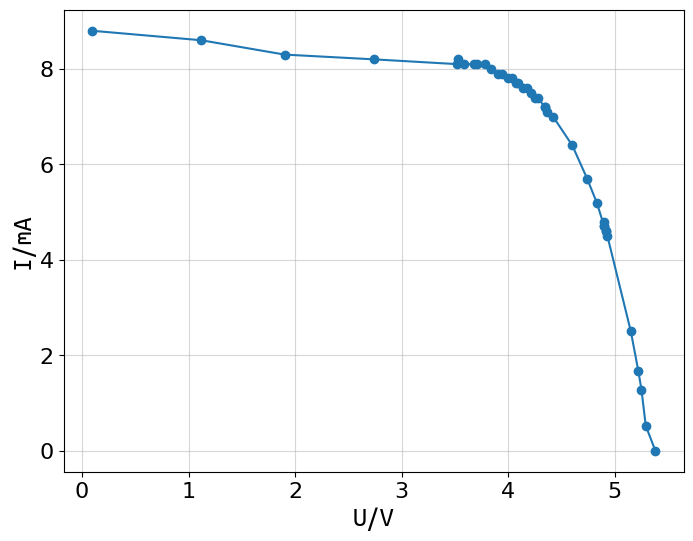

In [60]:
plt.figure(figsize=(8, 6))
lst = [(v, c) for v, c in zip(vol, cur)]
lst.sort()
plt.plot([p[0] for p in lst], [p[1] for p in lst], marker="o", ls="-")
del lst
plt.xlabel("U/V", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.xticks(fontsize=16)
plt.ylabel("I/mA", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()

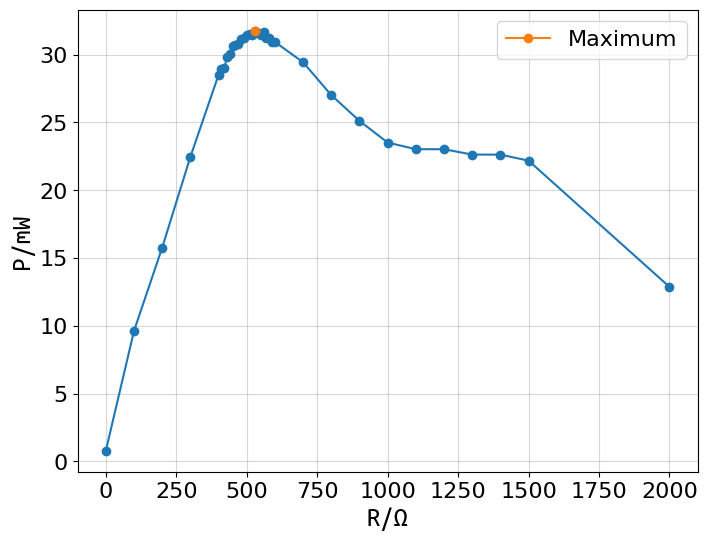

In [61]:
plt.figure(figsize=(8, 6))
plt.plot(
    [r for r, p in pwr.items() if r <= 2000],
    [p for r, p in pwr.items() if r <= 2000],
    marker="o",
    ls="-",
)
plt.plot(r_e, pwr[r_e], label="Maximum", marker="o")
plt.xlabel("R/Ω", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.xticks(fontsize=16)
plt.ylabel("P/mW", fontdict={"family": "Ubuntu Mono", "fontsize": 20})
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()